In [3]:
import os
print(f"I am currently in: {os.getcwd()}")
print(f"Files I can see here: {os.listdir('.')}")

I am currently in: C:\dev\AAV_Process_Modeling\notebooks
Files I can see here: ['.ipynb_checkpoints', '2026_04_13_generate_data.ipynb', '2026_04_19_query_tests.ipynb', 'aav_manufacturing.db']


In [4]:
import duckdb
import os

# Get the path of the folder holding this notebook, then go up one
project_root = os.path.dirname(os.getcwd())

# Connect to a database file (this creates it if it doesn't exist)
con = duckdb.connect('../aav_manufacturing.db') 

# 1. Create or replace the Telemetry and outcomes tables directly from the CSV
con.execute(f"CREATE OR REPLACE TABLE telemetry AS SELECT * FROM '{os.path.join(project_root, 'data', 'raw', 'telemetry_batches.csv')}'")
con.execute(f"CREATE OR REPLACE TABLE outcomes AS SELECT * FROM '{os.path.join(project_root, 'data', 'raw', 'batch_outcomes.csv')}'")

print(con.execute("SHOW TABLES").fetchall())

#close the connection to spare resources
con.close()

[('outcomes',), ('telemetry',)]


In [12]:
# Connect to the DB file in your current folder
con = duckdb.connect('aav_manufacturing.db')

In [6]:
import duckdb
import pandas as pd

# Query the top 5 batches by Titer
query = """
    SELECT Batch_ID, Final_Titer, Full_Empty_Ratio 
    FROM outcomes 
    ORDER BY Final_Titer DESC 
    LIMIT 5
    """

df_top = con.execute(query).df()
print("Top Performing Batches:")
display(df_top)



Top Performing Batches:


,Batch_ID,Final_Titer,Full_Empty_Ratio
0,LOT_025,1.694304,0.260982
1,LOT_010,1.686583,0.264169
2,LOT_001,1.681448,0.265977
3,LOT_026,1.640514,0.265054
4,LOT_024,1.598422,0.259548


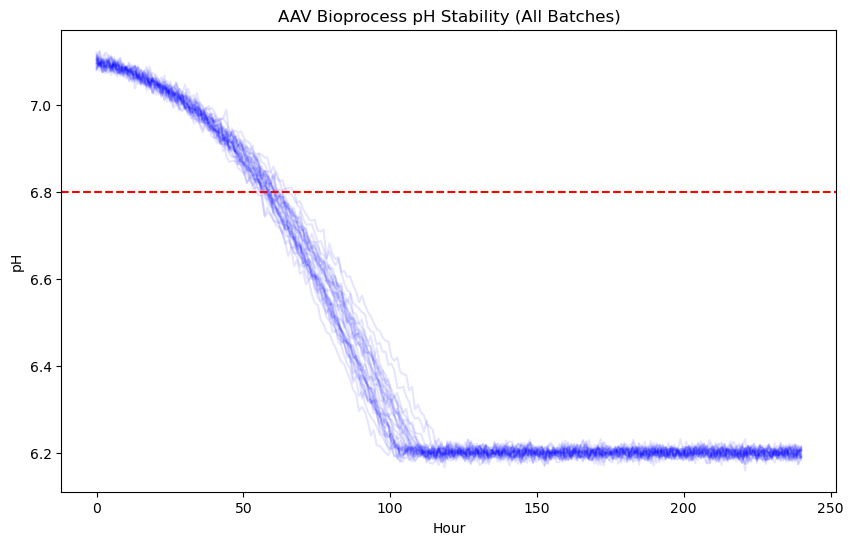

In [7]:
import matplotlib.pyplot as plt

# Pull pH data for all batches
df_ph = con.execute("SELECT Hour, pH, Batch_ID FROM telemetry").df()

plt.figure(figsize=(10, 6))
# We group by Batch_ID to plot a line for each individual run
for label, df in df_ph.groupby('Batch_ID'):
    plt.plot(df['Hour'], df['pH'], color='blue', alpha=0.1) # alpha makes lines semi-transparent

plt.axhline(y=6.8, color='red', linestyle='--', label='Critical pH Threshold')
plt.title('AAV Bioprocess pH Stability (All Batches)')
plt.xlabel('Hour')
plt.ylabel('pH')
plt.show()

In [11]:
#creates an index to make the query faster
con.execute("CREATE INDEX idx_batch_id ON telemetry (Batch_ID);")

ConnectionException: Connection Error: Connection already closed!

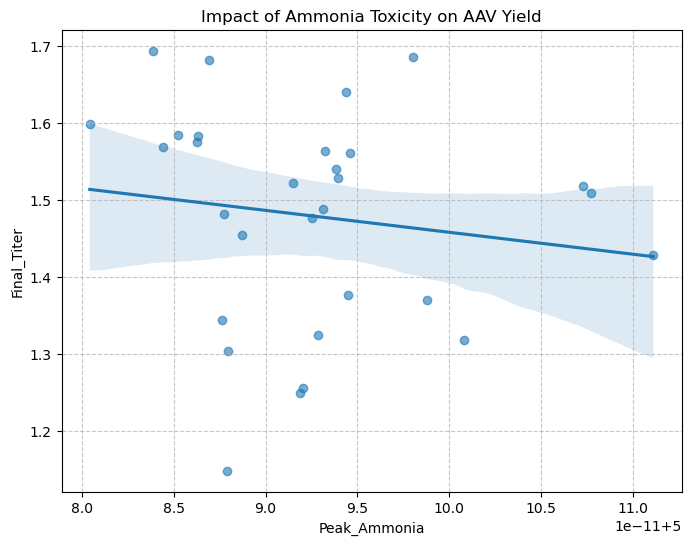

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Join the tables directly in SQL (Much faster than pd.merge)
query = """
SELECT 
    o.Batch_ID, 
    o.Final_Titer, 
    MAX(t.Ammonia) AS Peak_Ammonia
FROM outcomes o
JOIN telemetry t ON o.Batch_ID = t.Batch_ID
GROUP BY o.Batch_ID, o.Final_Titer
"""

df_corr = con.execute(query).df()

# 2. Visualize the relationship
plt.figure(figsize=(8, 6))
sns.regplot(data=df_corr, x='Peak_Ammonia', y='Final_Titer', scatter_kws={'alpha':0.6})

plt.title('Impact of Ammonia Toxicity on AAV Yield')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Success! Found 30 matches.


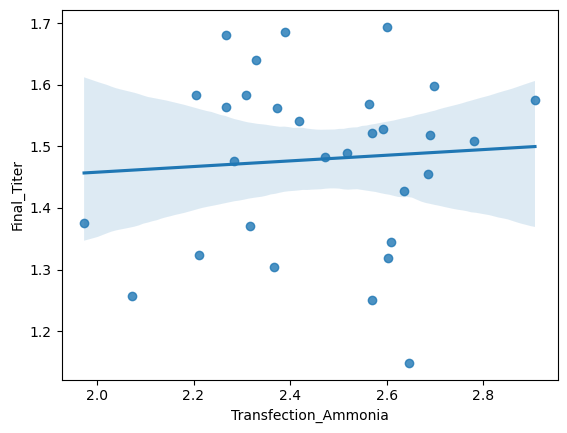

In [23]:
query = """
SELECT 
    o.Batch_ID, 
    o.Final_Titer, 
    t.Ammonia AS Transfection_Ammonia
FROM outcomes o
JOIN telemetry t ON o.Batch_ID = t.Batch_ID
WHERE ROUND(t.Hour, 0) = 72
"""

df_true_corr = con.execute(query).df()

if df_true_corr.empty:
    print("DataFrame is still empty! We need to check the 'Hour' values in the CSV.")
else:
    print(f"Success! Found {len(df_true_corr)} matches.")
    sns.regplot(data=df_true_corr, x='Transfection_Ammonia', y='Final_Titer')

In [10]:
con.close()